# SPEARMAN CODE

##### Note: Use control f with input "comment" to see lines to comment out / uncomment based on if you are using pure skill data, actual data, coin flip data, etc, or replace with a new line reflecting the dataset you are using. There are only two occurrences of this and helps keep the tables labeled correctly.

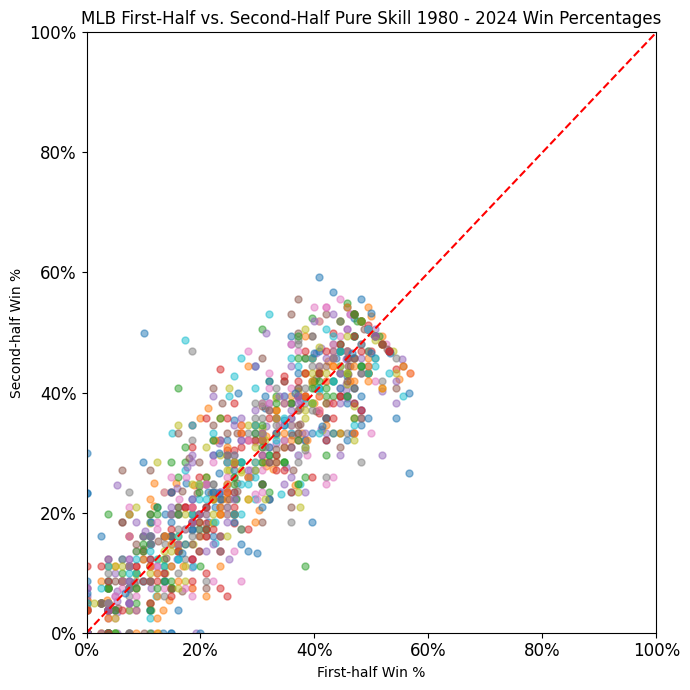

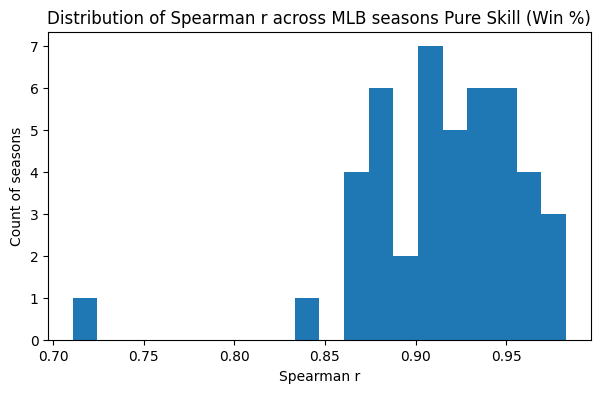


r value meanings:
r closer to 1: first half ranks are very predictive of second half ranks
r closer to 0: first half ranks are NOT very predictive of second half ranks
r negative: reverse tendency. high first half ranks predict low second half ranks, and vice versa


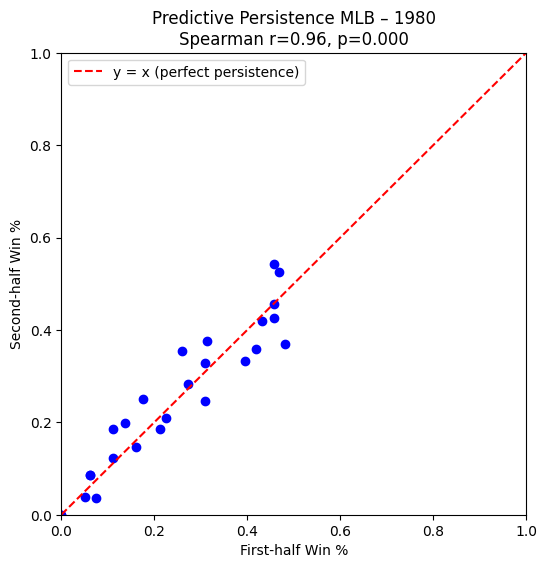

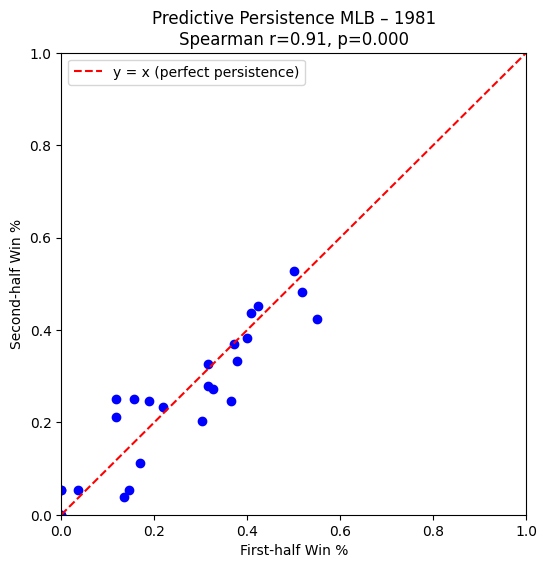

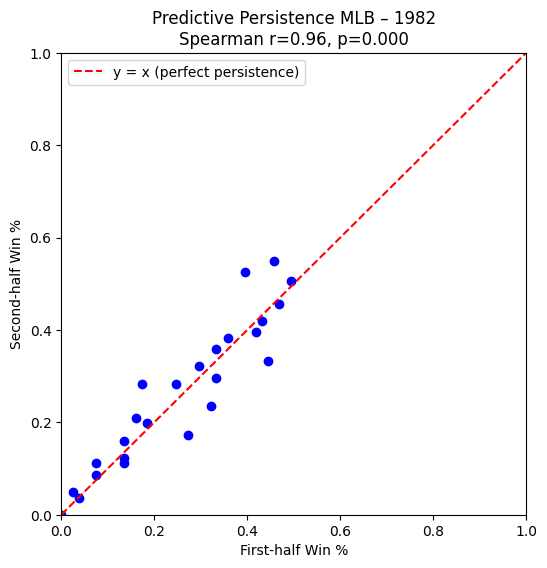

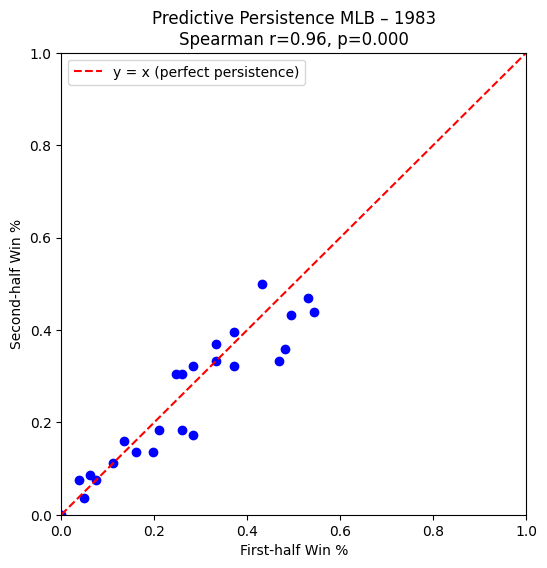

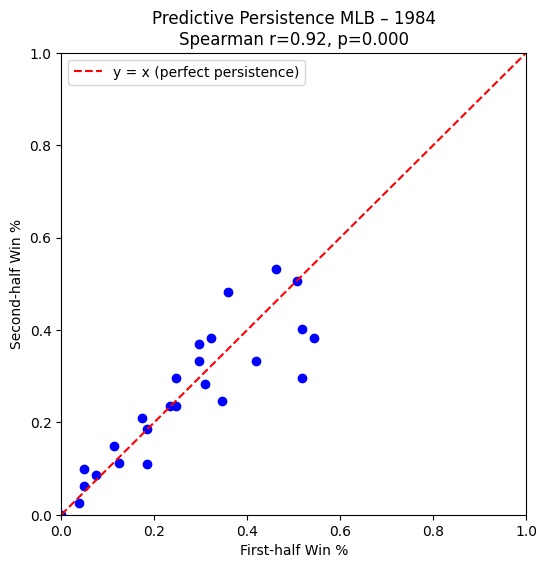

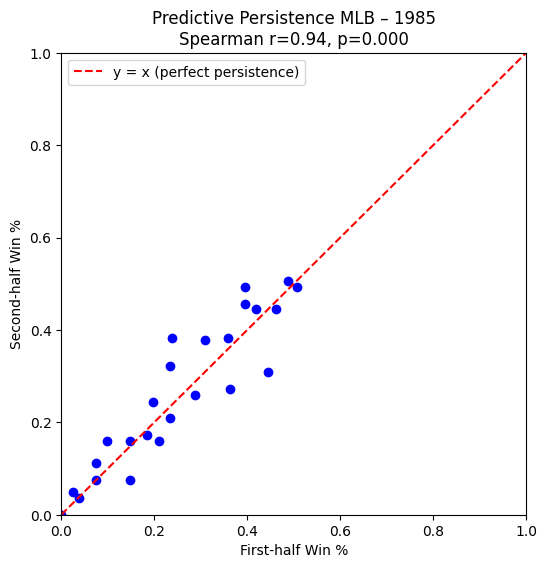

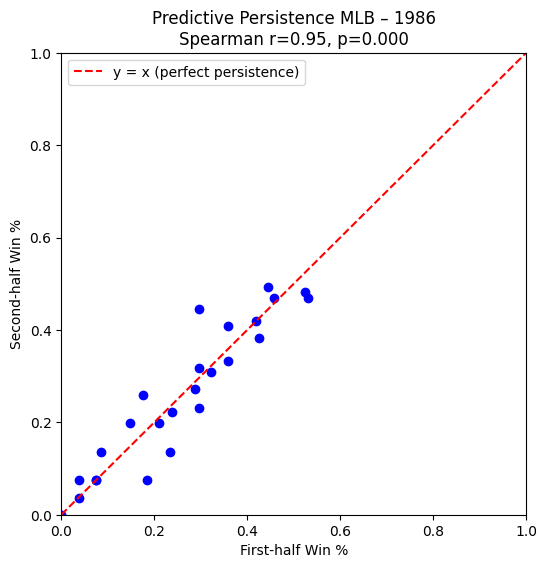

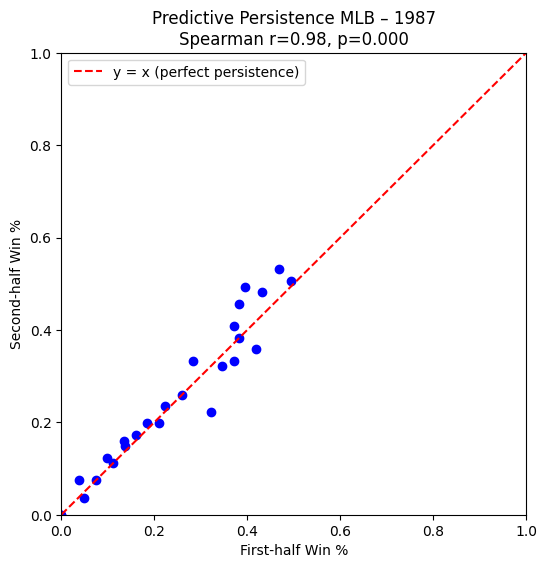

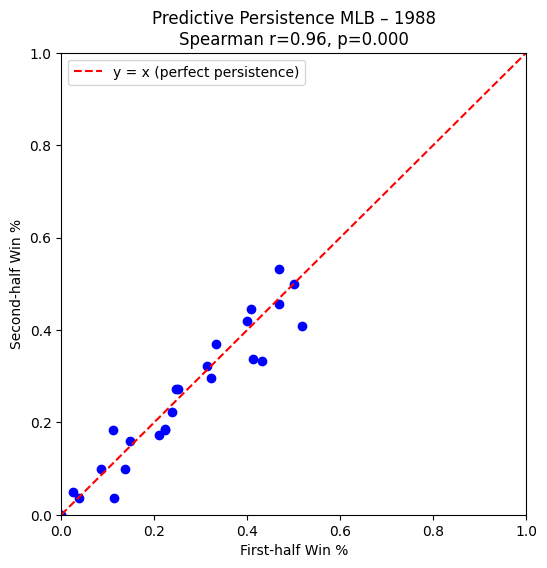

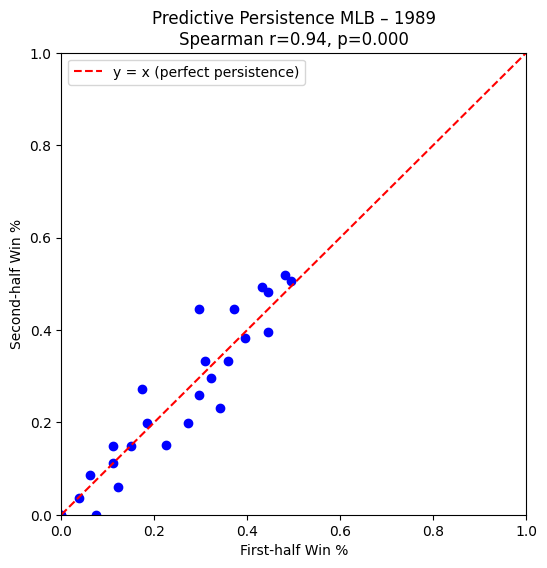

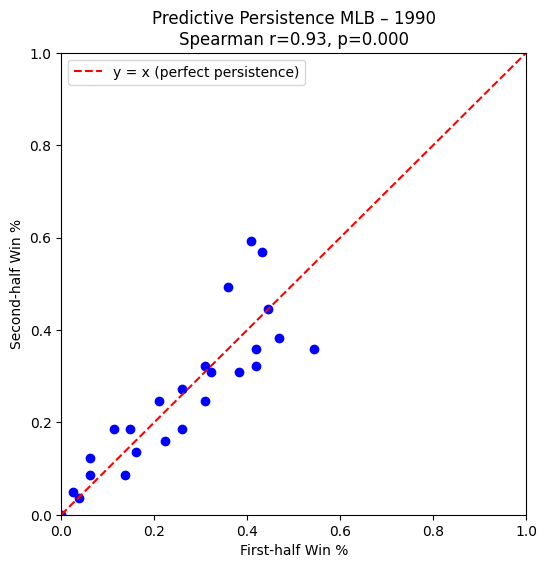

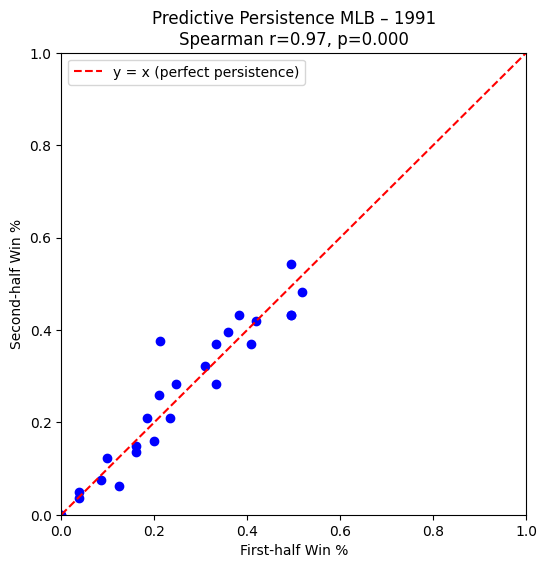

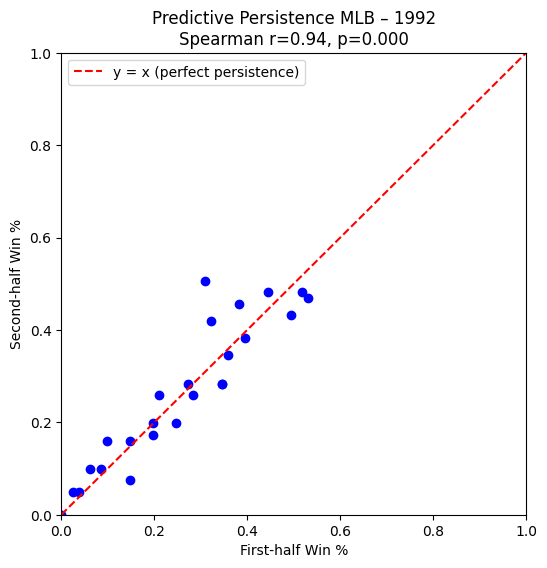

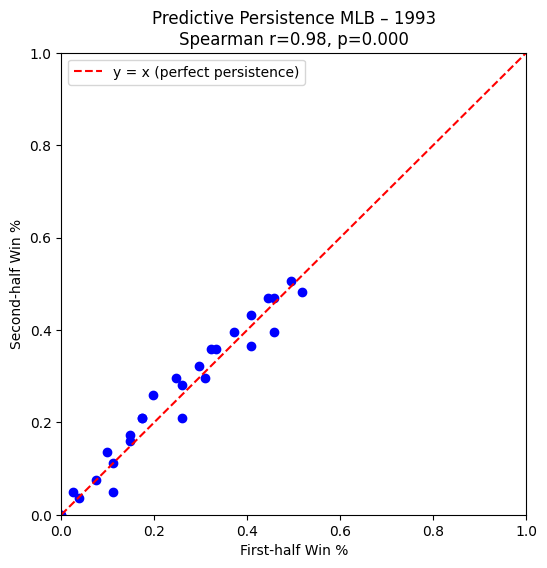

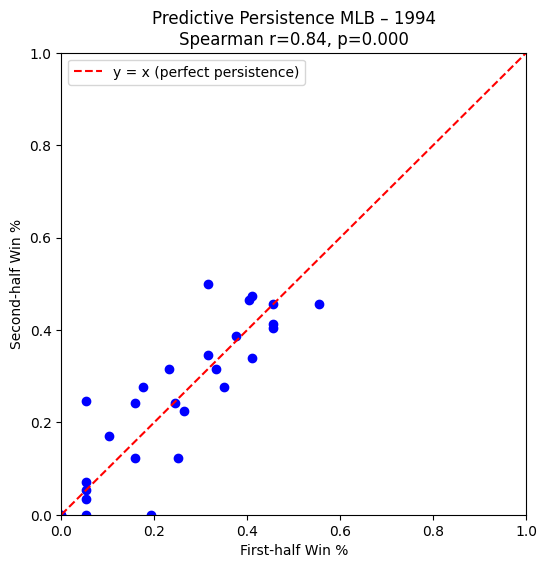

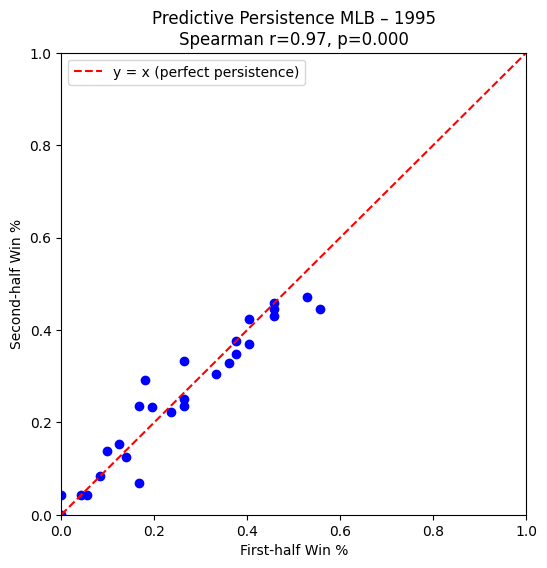

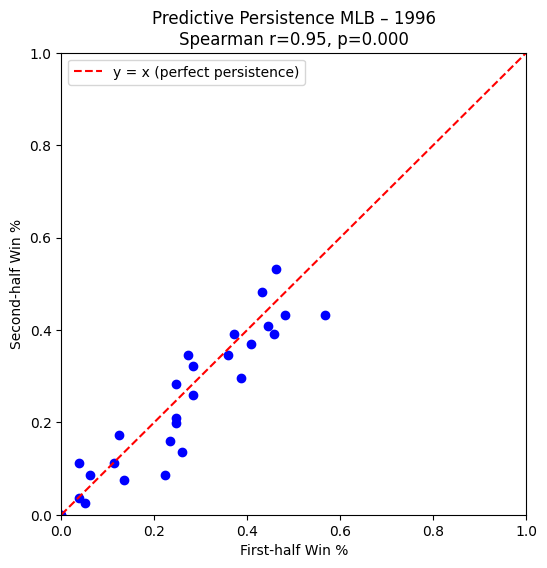

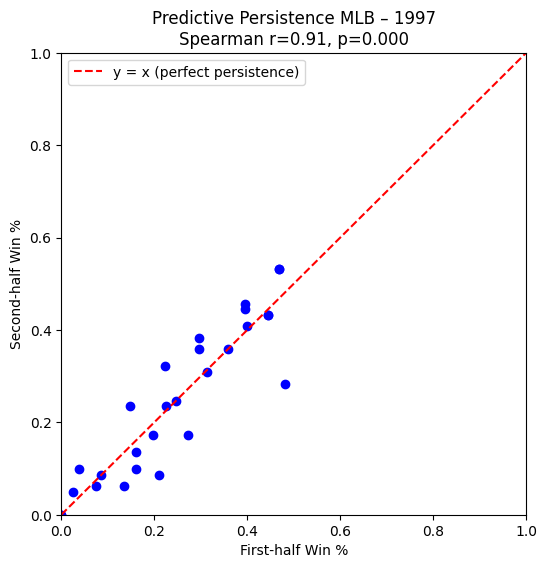

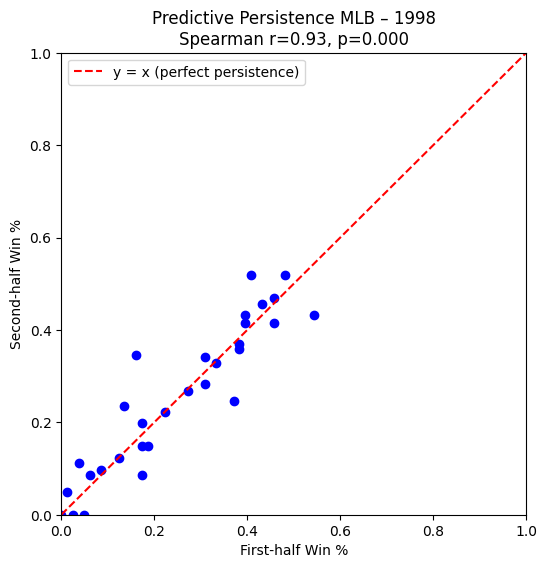

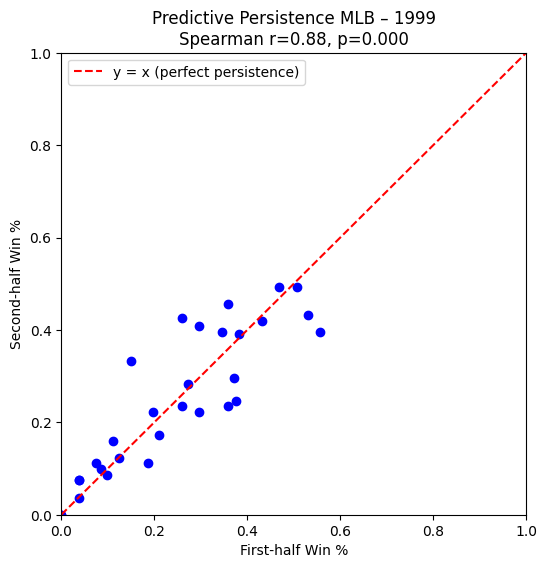

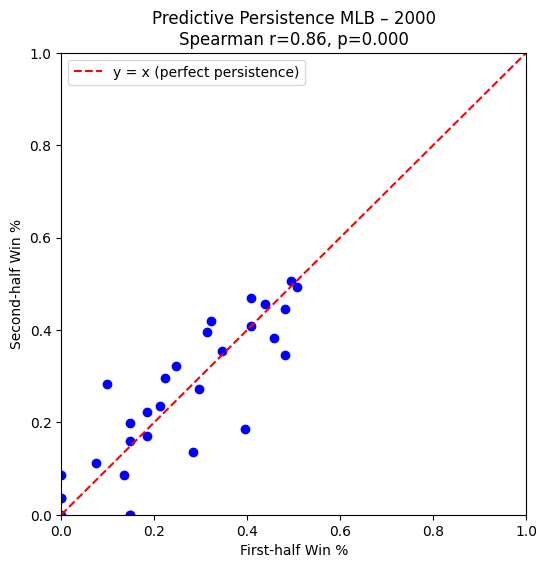

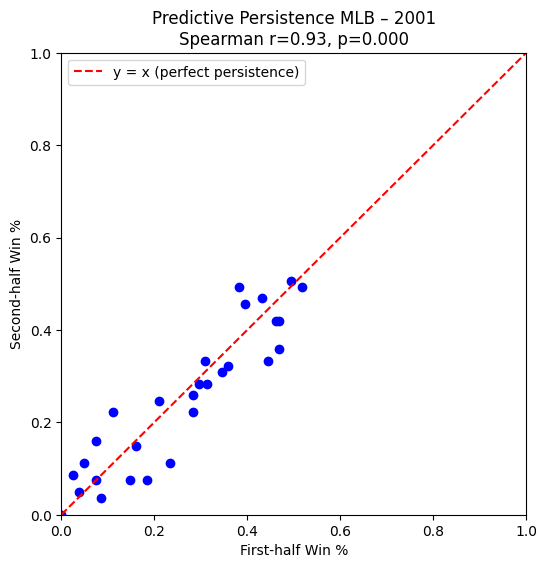

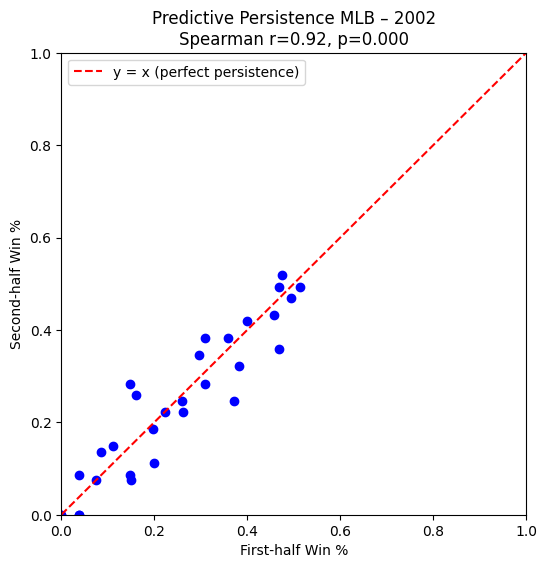

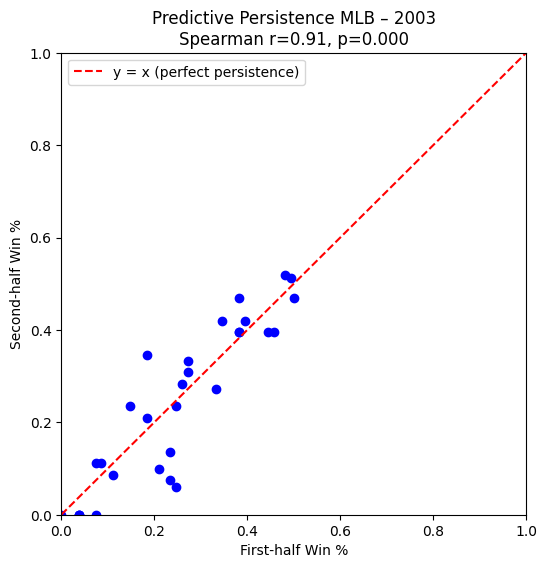

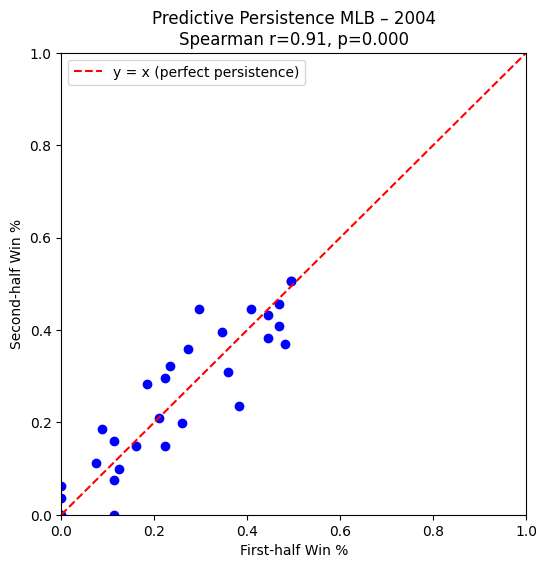

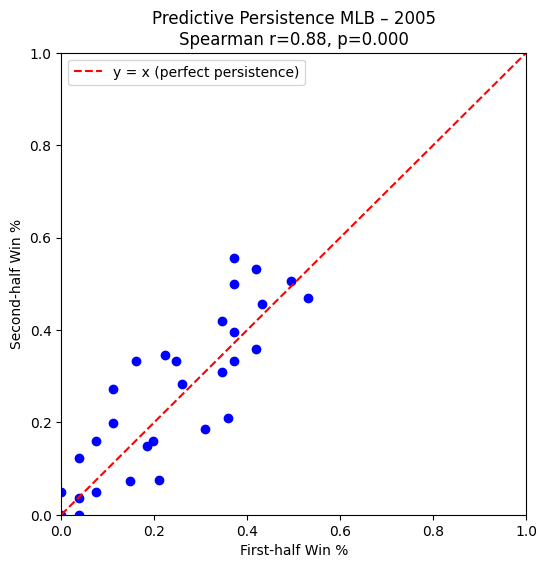

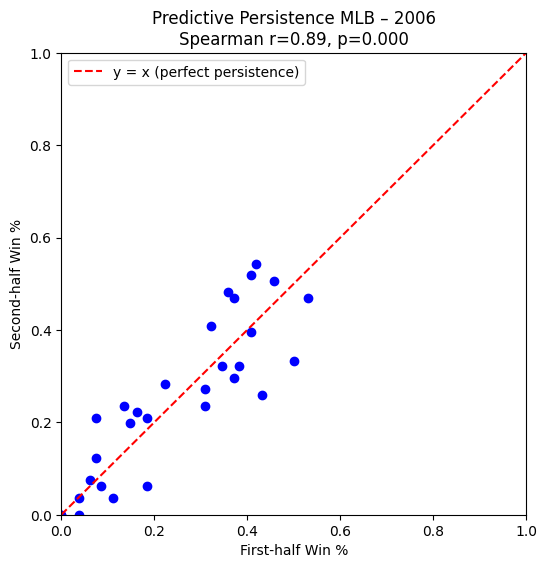

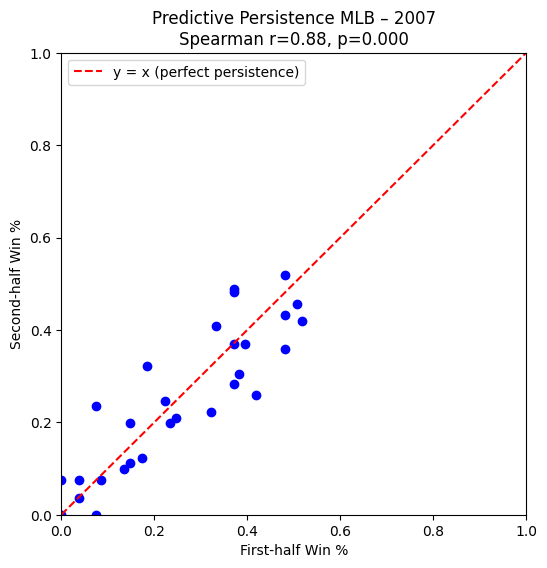

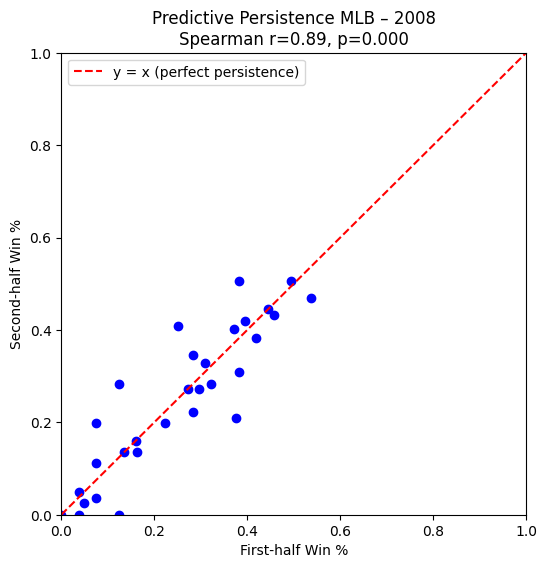

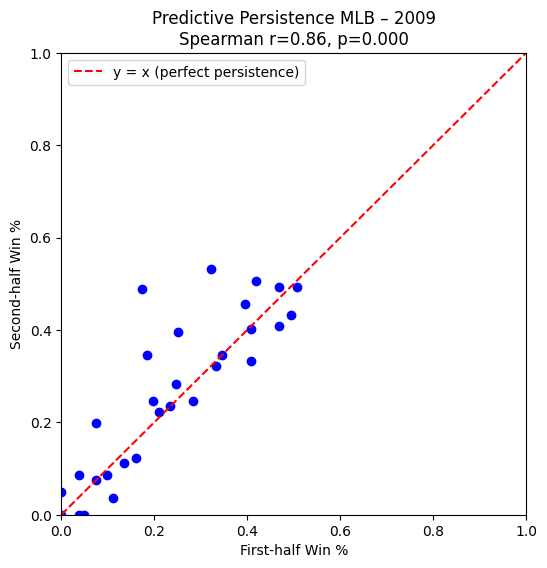

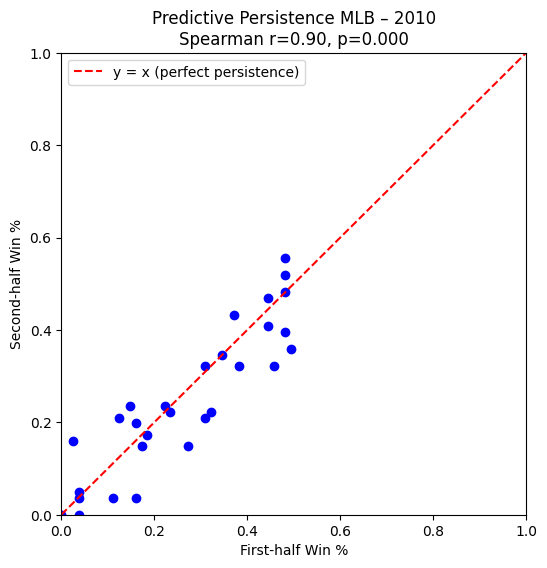

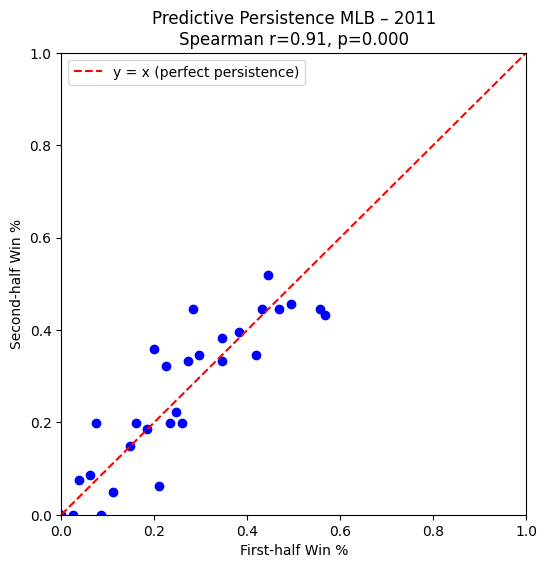

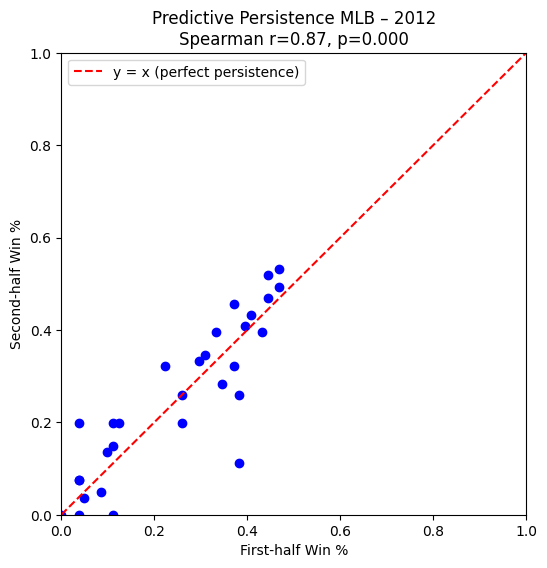

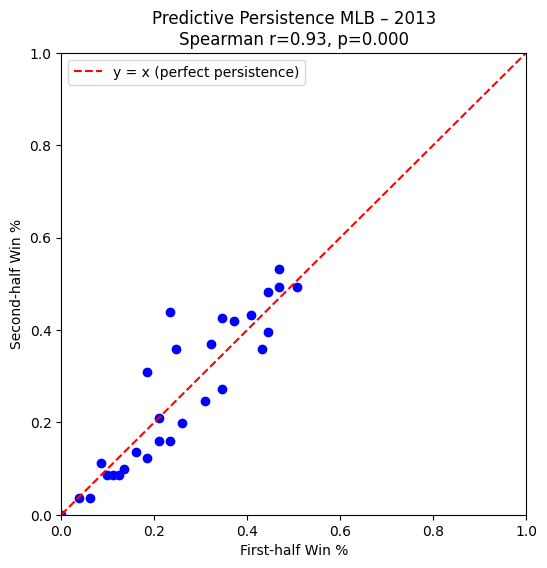

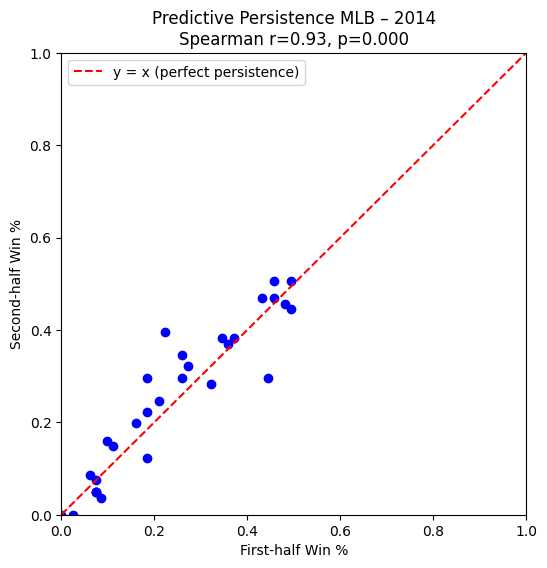

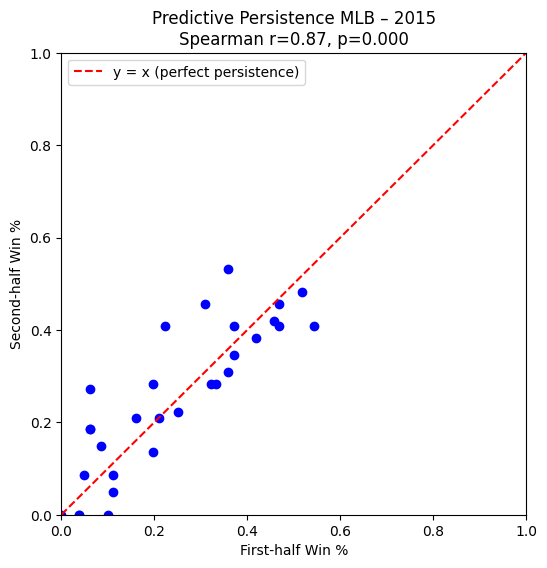

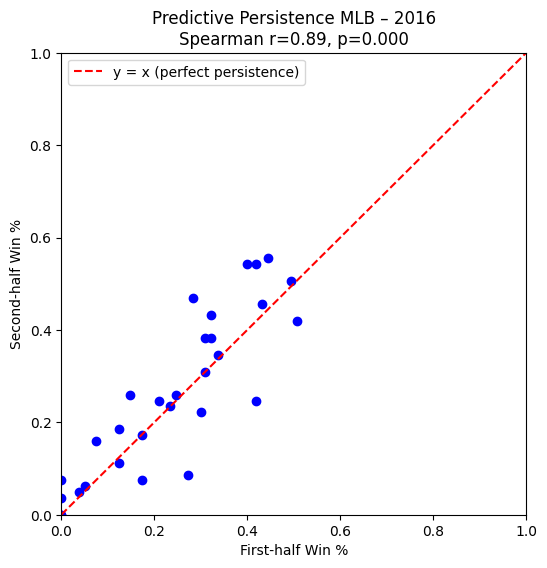

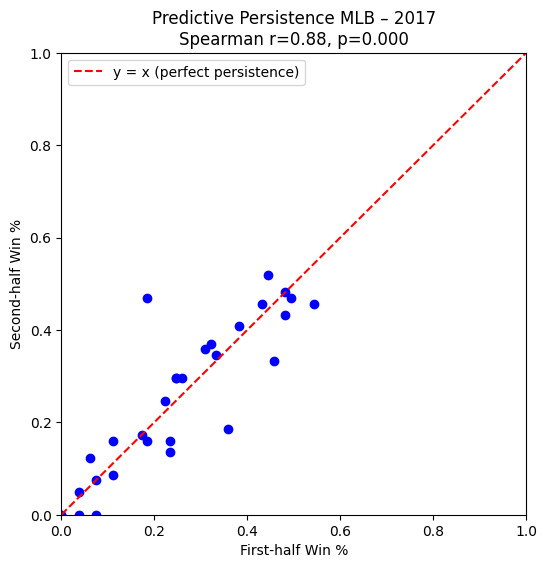

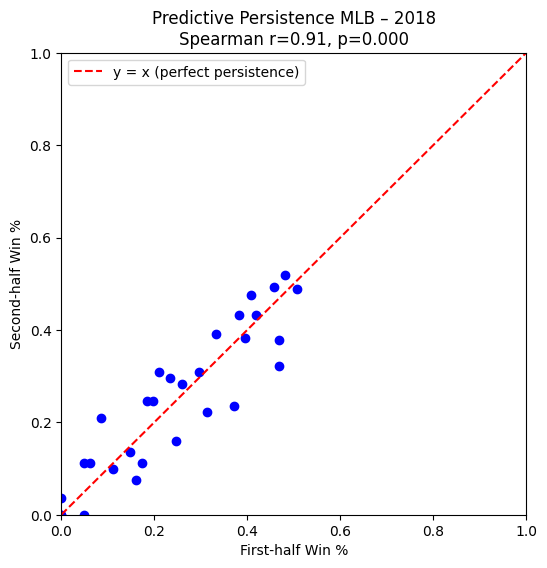

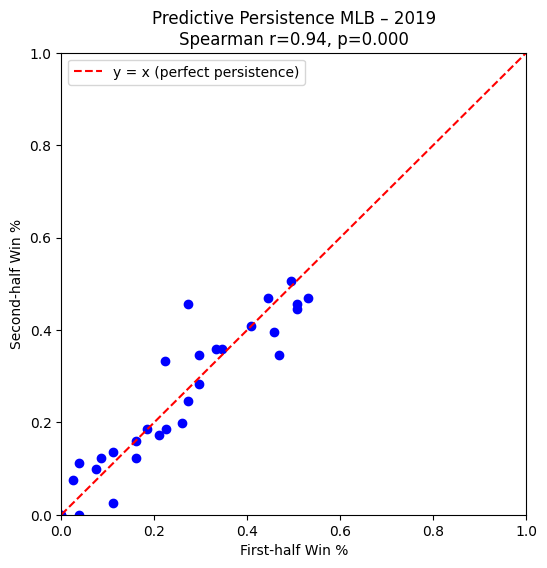

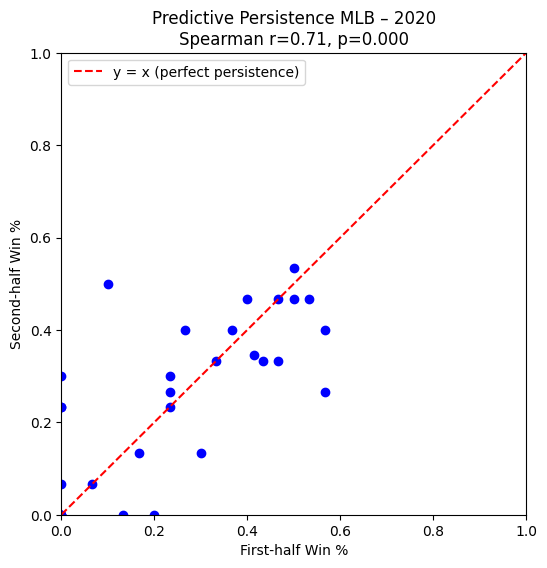

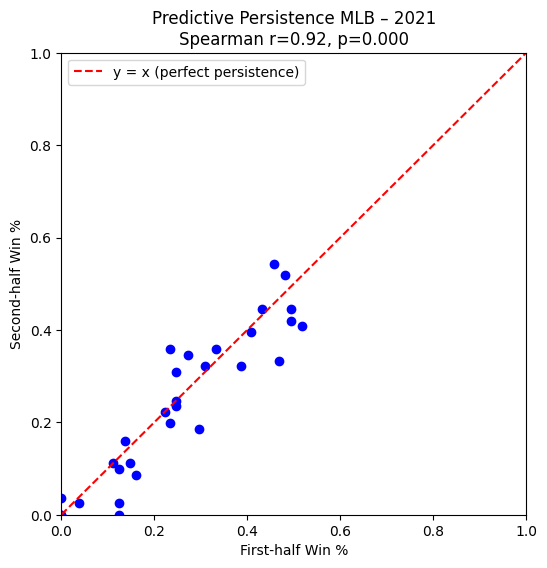

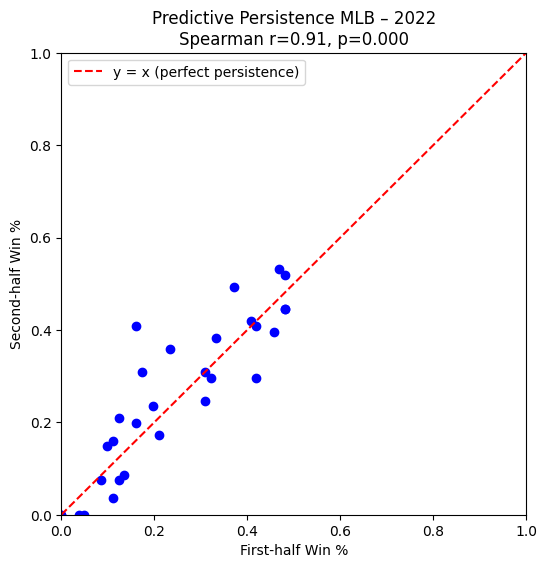

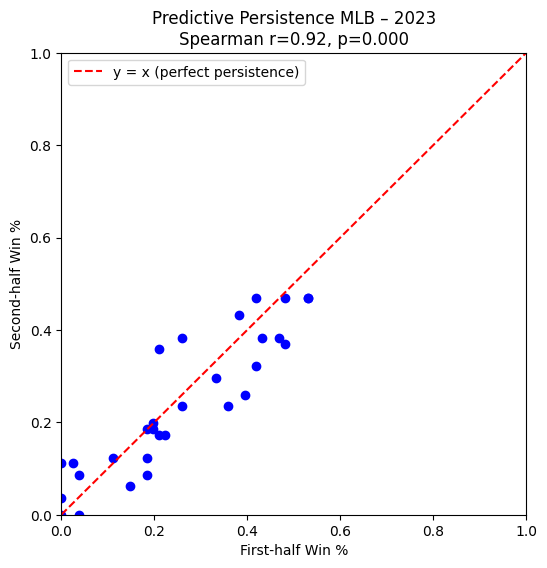

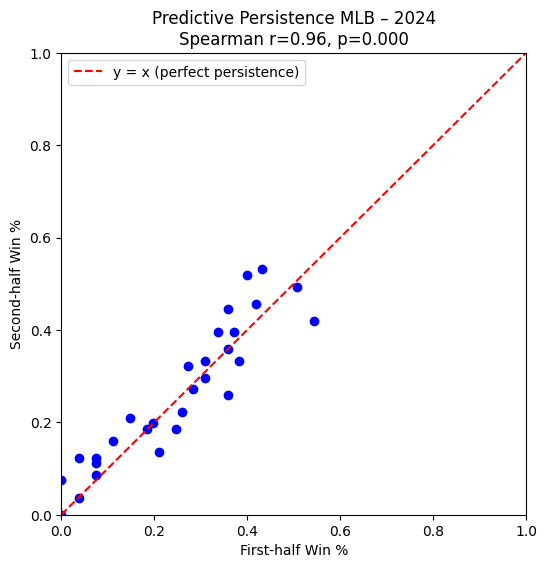

Saved MLB per-season Spearman stats to: mlb_spearman_by_season_pure_skill.csv


,season,n_teams,spearman_r,spearman_p
0,1980,26,0.955309,3.333029e-14
1,1981,26,0.912103,8.907884e-11
2,1982,26,0.958048,1.582459e-14
3,1983,26,0.957348,1.922943e-14
4,1984,26,0.920021,2.991861e-11
5,1985,26,0.940895,8.854752e-13
6,1986,26,0.945168,3.678964e-13
7,1987,26,0.979805,2.740928e-18
8,1988,26,0.958747,1.298224e-14
9,1989,26,0.943817,4.892805e-13


In [48]:
# ============================================================
# Predictive Persistence Analysis (league-selectable) NEW CODE
# ============================================================

# 0) Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.ticker as mtick

# ------------------------------------------------------------
# 1) Load the dataset: (choose league + file)
# ------------------------------------------------------------

LEAGUE = "MLB"  # <-- set to "NBA", "NFL", or "MLB"

# for coin flip, comment out if using different dataset
# prob = 0.5  # set 0.5, 0.7, 0.8, etc.
# DATA_PATH = f'us_combined_data_coin_flip_{prob:.1f}.csv'
# for coin flip, comment out if using different dataset

# for pure skill, comment out if using different dataset
DATA_PATH = f'us_combined_pure_skill.csv'
# for pure skill, comment out if using different dataset

# for actual data, comment out if using different dataset
# DATA_PATH = f'us_combined_data.csv'
# for actual data, comment out if using different dataset

# ---- detect pure-skill file name to switch win rule ----
USE_RESULT = ('pure_skill' in DATA_PATH.lower())

df = pd.read_csv(DATA_PATH)
df = df[df['league'] == LEAGUE]
df['date'] = pd.to_datetime(df['date'])

# ------------------------------------------------------------
# 2) Convert into "team-game" format
# We build a table where each original game row
# is viewed from one of the team's point of view.
# Then we can look at, for each team, a section in the table which
# represents their wins and losses throughout the season
# ------------------------------------------------------------

## Team1 Perspective ##
t1 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team1'],
    'opponent': df['team2'],
    'points_for': df['score1'],
    'points_against': df['score2'],
})
# add team's point differential for each game
t1['margin'] = t1['points_for'] - t1['points_against']
# add team's win flag for each game. 1 = win, 0 = loss
t1['win'] = (df['result'] == 1).astype(int) if USE_RESULT else (t1['margin'] > 0).astype(int)

## Team2 Perspective ##
t2 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team2'],
    'opponent': df['team1'],
    'points_for': df['score2'],
    'points_against': df['score1'],
})
# add team's point differential for each game
t2['margin'] = t2['points_for'] - t2['points_against']
# add team's win flag for each game 1 = win, 0 = loss
t2['win'] = (df['result'] == 0).astype(int) if USE_RESULT else (t2['margin'] > 0).astype(int)

# Combine both perspectives
# Make a single table with one row per team per game
# (each real game appears twice: once for each team’s perspective).

# stacks rows, and then reindexes the rows to go from row 0 to row N-1
team_games = pd.concat([t1, t2], ignore_index=True)
# reorders rows so they are grouped by season, then by team, then by date
# reindexes the rows to go from row 0 to row N-1, delete old row lab\
team_games = team_games.sort_values(['season','team','date']).reset_index(drop=True)

# ------------------------------------------------------------
# 3) Helper functions
# ------------------------------------------------------------

# define function which takes in the team games, and returns, for
# each season and team, the team's first-half and second-half win percentages
def compute_first_second_halves(team_games):
    rows = [] # initializes an empty list
    # for loop groups team_games by season and team, where
    # (season, team) is the current group key, and
    # grp is a DataFrame containing only that team's rows in the season
    for (season, team), grp in team_games.groupby(['season','team']):
        grp = grp.sort_values('date') # sorts grp by date
        n = len(grp)
        if n < 2: # if game has < 2 games, can't split into halves, so skip
            continue
        split = n // 2 # gives index at which to split the season into two halves
        first = grp.iloc[:split] # take first split rows as first half
        second = grp.iloc[split:]# take second split rows as second half
        if len(first) == 0 or len(second) == 0: # if n was 1, skip
            continue
        m1, m2 = first['win'].mean(), second['win'].mean() # mean = fraction of wins
        # store summary row for this (seaosn, team)
        rows.append({'season': season, 'team': team,
                     'first': m1, 'second': m2,
                     'n_games': n})
    # return the collected list of dictionaries into a DataFrame with cols
    # season, team, first, second, n_games
    return pd.DataFrame(rows)

# define function which plots first-half and second-half win percentage
# for all teams in one season
def plot_season_scatter(grp, season):
    # compute Spearman rank correlation and p_value between first half and second half win percentage
    r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
    plt.figure(figsize=(6,6)) # creates square figure
    plt.scatter(grp['first'], grp['second'], color='blue') # plots one point per team
    # draw y = x line
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    # fix x and y axis to [0,1], label axes, title graph
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('First-half Win %')
    plt.ylabel('Second-half Win %')
    plt.title(f'Predictive Persistence {LEAGUE} – {season}\nSpearman r={r_s:.2f}, p={p_s:.3f}')
    plt.legend() # shows label on y = x line
    plt.show()

# define function which takes output of compute_first_second_halves (one row per team-season
# with 'first' and 'second' win percentages) and computes a per-season Spearman correlation.
def season_correlations(first_second_df):
    out = []  # collect one dict per season with Spearman stats
    for season, grp in first_second_df.groupby('season'):
        # Need variation and enough teams; otherwise correlation is undefined or meaningless
        if grp['first'].nunique() <= 1 or grp['second'].nunique() <= 1 or len(grp) < 3:
            continue
          # rank each array
        r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
        out.append({
            'season': season,
            'n_teams': len(grp),
            'spearman_r': r_s,
            'spearman_p': p_s
        })
      # store stats for the season: number of teams,
      # spearman r-val (correlation between first half and second half win %
      # across teams in that season), p-val
    return pd.DataFrame(out).sort_values('season')


# ------------------------------------------------------------
# 4) Run predictive persistence analysis
# ------------------------------------------------------------

# get per team per season summaries
fs_win = compute_first_second_halves(team_games)
# give the summaries to the correlation helper
corr_win = season_correlations(fs_win)


# ------------------------------------------------------------
# 5) One combined plot with ALL seasons overlaid
#    Title format: "Predictive Persistence LEAGUE - [lowest season - highest season]"
# ------------------------------------------------------------

if not fs_win.empty:
    min_season = int(df.loc[df['league'].eq(LEAGUE), 'season'].min())
    max_season = int(df.loc[df['league'].eq(LEAGUE), 'season'].max())

    plt.figure(figsize=(7,7))
    # Overlay each season's points; label only if few seasons to avoid clutter
    for season, grp in fs_win.groupby('season'):
        plt.scatter(grp['first'], grp['second'], alpha=0.5, s=25, label=str(season))

    # create plot
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    plt.xlim(0, 1)
    plt.ylim(0, 1)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    # axis labels for presentation
  #  plt.xlabel('First-half Win Percentage', fontsize=20)
  #  plt.ylabel('Second-half Win Percentage', fontsize=20)
    # end of axis labels for presentation
    # tick labels (optional)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    # end of tick labels for presentation
    plt.xlabel('First-half Win %') # commented out since small for presentation
    plt.ylabel('Second-half Win %') # commented out since small for presentation
    # adjust title based on file
    # plt.title(f'{LEAGUE} First-Half vs. Second-Half Coin Flip ({prob}) {min_season} - {max_season} Win Percentages') # for coin clip dataset (comment out if other set)
    plt.title(f'{LEAGUE} First-Half vs. Second-Half Pure Skill {min_season} - {max_season} Win Percentages') # for pure skill dataset (comment out if other set)
    # plt.title(f'{LEAGUE} First-Half vs. Second-Half {min_season} - {max_season} Win Percentages') # for actual dataset (comment out if other set)
    # adjust title based on file
    #  show labels only if the number of seasons is small
    if fs_win['season'].nunique() <= 15:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6) Histogram of Spearman correlations across seasons
# ------------------------------------------------------------

if not corr_win.empty:
    plt.figure(figsize=(7,4))
    plt.hist(corr_win['spearman_r'].dropna(), bins=20)
    # adjust title based on file
    # plt.title(f'Distribution of Spearman r across {LEAGUE} seasons Coin Flip ({prob}) (Win %)') # for coin clip dataset (comment out if other set)
    plt.title(f'Distribution of Spearman r across {LEAGUE} seasons Pure Skill (Win %)') # for pure skill dataset (comment out if other set)
    # plt.title(f'Distribution of Spearman r across {LEAGUE} seasons (Win %)') # for actual dataset (comment out if other set)
    # adjust title based on file
    plt.xlabel('Spearman r')
    plt.ylabel('Count of seasons')
    plt.show()
    print("\nr value meanings:")
    print("r closer to 1: first half ranks are very predictive of second half ranks")
    print("r closer to 0: first half ranks are NOT very predictive of second half ranks")
    print("r negative: reverse tendency. high first half ranks predict low second half ranks, and vice versa")

# ------------------------------------------------------------
# 7) Plot scatterplots for ALL seasons
# ------------------------------------------------------------

for season, grp in fs_win.groupby('season'):
    if len(grp) >= 3: # don't print scatter plot if less than 3 teams
        plot_season_scatter(grp, season)

# ============================================================
# 8) Save per-season Spearman (r, p) to CSV
# ============================================================

# Make a tidy table (already LEAGUE-only because df was filtered above)
corr_out = corr_win[['season', 'n_teams', 'spearman_r', 'spearman_p']].copy()
corr_out = corr_out.sort_values('season').reset_index(drop=True)

# Choose an output path (auto-suffix based on file)
suffix = "_pure_skill" if USE_RESULT else ("_coinflip" if "coin_flip" in DATA_PATH.lower() else "")
out_path = f"{LEAGUE.lower()}_spearman_by_season{suffix}.csv"

corr_out.to_csv(out_path, index=False)
print(f"Saved {LEAGUE} per-season Spearman stats to: {out_path}")
display(corr_out.head(10))


# Combining CSV Files

In [35]:
# ============================================================
# Combine league CSVs and save to /var COIN FLIP
# ============================================================
from pathlib import Path
import pandas as pd

save_dir = Path("/var")
search_dirs = [Path("."), Path("/var")]  # where to look for the inputs

def find_league_csv(league_lower: str, prob_value: float) -> Path:
    """
    Find a CSV named like '<league>_spearman_by_season_prob_<prob>.csv'.
    If an exact match for the current prob isn't found, fall back to the latest match.
    """
    # Try exact match first
    exact = [d / f"{league_lower}_spearman_by_season_prob_{prob_value:.1f}.csv" for d in search_dirs]
    for p in exact:
        if p.exists():
            return p
    # Fallback: any prob
    hits = []
    for d in search_dirs:
        hits.extend(d.glob(f"{league_lower}_spearman_by_season_prob_*.csv"))
    if hits:
        return sorted(hits)[-1]
    raise FileNotFoundError(f"Could not find CSV for {league_lower.upper()} in {search_dirs}")

# Locate inputs
nba_fp = find_league_csv("nba", prob)
mlb_fp = find_league_csv("mlb", prob)
nfl_fp = find_league_csv("nfl", prob)

# Read, tag with league, and keep consistent columns
frames = []
for league, fp in [("NBA", nba_fp), ("MLB", mlb_fp), ("NFL", nfl_fp)]:
    dfl = pd.read_csv(fp)
    dfl.insert(0, "league", league)
    keep = [c for c in ["league", "season", "n_teams", "spearman_r", "spearman_p"] if c in dfl.columns]
    frames.append(dfl[keep])

combined = pd.concat(frames, ignore_index=True)

# Order rows: NBA -> MLB -> NFL, then by season ascending
combined["league"] = pd.Categorical(combined["league"], categories=["NBA", "MLB", "NFL"], ordered=True)
if "season" in combined.columns:
    combined = combined.sort_values(["league", "season"]).reset_index(drop=True)
else:
    combined = combined.sort_values(["league"]).reset_index(drop=True)

# Save to /var
out_path = save_dir / f"combined_spearman_by_season_prob_{prob:.1f}.csv"
combined.to_csv(out_path, index=False)
print(f"Saved combined CSV to: {out_path}")
display(combined.head(20))



Saved combined CSV to: /var/combined_spearman_by_season_prob_0.5.csv


,league,season,n_teams,spearman_r,spearman_p
0,NBA,1949,17,0.034654,0.894955
1,NBA,1950,11,-0.157895,0.642881
2,NBA,1951,10,-0.142860,0.693794
3,NBA,1952,10,0.316770,0.372510
4,NBA,1953,9,-0.296110,0.439125
5,NBA,1954,8,0.658733,0.075667
6,NBA,1955,8,0.147740,0.726992
7,NBA,1956,8,0.314911,0.447418
8,NBA,1957,8,0.785409,0.020899
9,NBA,1958,8,0.558293,0.150380


In [50]:
# ============================================================
# Combine league CSVs (plain filenames) and save to /var PURE SKILL
# ============================================================
from pathlib import Path
import pandas as pd

save_dir = Path("/var")
search_dirs = [Path("."), Path("/var")]  # where to look for the inputs

def find_simple_csv(filename: str) -> Path:
    """Find an exact CSV filename in search_dirs."""
    for d in search_dirs:
        p = d / filename
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {filename} in {search_dirs}")

# Locate inputs (plain filenames, no 'prob' suffix)
nba_fp = find_simple_csv("nba_spearman_by_season_pure_skill.csv")
mlb_fp = find_simple_csv("mlb_spearman_by_season_pure_skill.csv")
nfl_fp = find_simple_csv("nfl_spearman_by_season_pure_skill.csv")

# Read, tag with league, and keep consistent columns
frames = []
for league, fp in [("NBA", nba_fp), ("MLB", mlb_fp), ("NFL", nfl_fp)]:
    dfl = pd.read_csv(fp)
    dfl.insert(0, "league", league)
    keep = [c for c in ["league", "season", "n_teams", "spearman_r", "spearman_p"] if c in dfl.columns]
    frames.append(dfl[keep])

combined_spearman_by_season_pure_skill = pd.concat(frames, ignore_index=True).drop_duplicates()

# Order rows: NBA -> MLB -> NFL, then by season ascending
combined_spearman_by_season_pure_skill["league"] = pd.Categorical(
    combined_spearman_by_season_pure_skill["league"],
    categories=["NBA", "MLB", "NFL"],
    ordered=True
)

if "season" in combined_spearman_by_season_pure_skill.columns:
    combined_spearman_by_season_pure_skill = (
        combined_spearman_by_season_pure_skill.sort_values(["league", "season"]).reset_index(drop=True)
    )
else:
    combined_spearman_by_season_pure_skill = combined_spearman_by_season_pure_skill.sort_values(["league"]).reset_index(drop=True)

# Save to /var with output name
out_path = save_dir / "combined_spearman_by_season_pure_skill.csv"
combined_spearman_by_season_pure_skill.to_csv(out_path, index=False)
print(f"Saved combined CSV to: {out_path}")

# display
display(combined_spearman_by_season_pure_skill.head(20))


Saved combined CSV to: /var/combined_spearman_by_season_pure_skill.csv


,league,season,n_teams,spearman_r,spearman_p
0,NBA,1949,17,0.884663,2.410114e-06
1,NBA,1950,11,0.952166,6.254560e-06
2,NBA,1951,10,0.902456,3.515764e-04
3,NBA,1952,10,0.945140,3.707957e-05
4,NBA,1953,9,0.764733,1.637769e-02
5,NBA,1954,8,0.902708,2.137647e-03
6,NBA,1955,8,0.879582,3.980559e-03
7,NBA,1956,8,0.951807,2.698078e-04
8,NBA,1957,8,0.970077,6.548559e-05
9,NBA,1958,8,0.994030,5.296154e-07


In [49]:
# ============================================================
# Combine league CSVs (plain filenames) and save to /var ACTUAL
# ============================================================
from pathlib import Path
import pandas as pd

save_dir = Path("/var")
search_dirs = [Path("."), Path("/var")]  # where to look for the inputs

def find_simple_csv(filename: str) -> Path:
    """Find an exact CSV filename in search_dirs."""
    for d in search_dirs:
        p = d / filename
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {filename} in {search_dirs}")

# Locate inputs (plain filenames, no 'prob' suffix)
nba_fp = find_simple_csv("nba_spearman_by_season.csv")
mlb_fp = find_simple_csv("mlb_spearman_by_season.csv")
nfl_fp = find_simple_csv("nfl_spearman_by_season.csv")

# Read, tag with league, and keep consistent columns
frames = []
for league, fp in [("NBA", nba_fp), ("MLB", mlb_fp), ("NFL", nfl_fp)]:
    dfl = pd.read_csv(fp)
    dfl.insert(0, "league", league)
    keep = [c for c in ["league", "season", "n_teams", "spearman_r", "spearman_p"] if c in dfl.columns]
    frames.append(dfl[keep])

combined_spearman_by_season = pd.concat(frames, ignore_index=True).drop_duplicates()

# Order rows: NBA -> MLB -> NFL, then by season ascending
combined_spearman_by_season["league"] = pd.Categorical(
    combined_spearman_by_season["league"],
    categories=["NBA", "MLB", "NFL"],
    ordered=True
)

if "season" in combined_spearman_by_season.columns:
    combined_spearman_by_season = (
        combined_spearman_by_season.sort_values(["league", "season"]).reset_index(drop=True)
    )
else:
    combined_spearman_by_season = combined_spearman_by_season.sort_values(["league"]).reset_index(drop=True)

# Save to /var with the correct name
out_path = save_dir / "combined_spearman_by_season.csv"
combined_spearman_by_season.to_csv(out_path, index=False)
print(f"Saved combined CSV to: {out_path}")

# display
display(combined_spearman_by_season.head(20))



Saved combined CSV to: /var/combined_spearman_by_season.csv


,league,season,n_teams,spearman_r,spearman_p
0,NBA,1949,17,0.734029,0.000795
1,NBA,1950,11,0.843012,0.001117
2,NBA,1951,10,0.643991,0.044482
3,NBA,1952,10,0.750014,0.012475
4,NBA,1953,9,0.737288,0.023402
5,NBA,1954,8,0.454554,0.257834
6,NBA,1955,8,0.078087,0.854181
7,NBA,1956,8,-0.282214,0.498274
8,NBA,1957,8,0.481963,0.226511
9,NBA,1958,8,0.745122,0.033884
